  # Task 4

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [3]:
data = pd.read_csv("clear_bank.csv")
data

,Unnamed: 0,age,marital,education,default,balance,housing,loan,day,duration,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,0,30,1,0,0,1787,0,0,19,79,...,0,0,0,0,0,1,0,0,0,1
1,1,33,1,1,0,4789,1,1,11,220,...,0,0,0,1,0,0,0,0,0,0
2,2,35,2,2,0,1350,1,0,16,185,...,0,0,0,0,0,0,0,0,0,0
3,3,30,1,2,0,1476,1,1,3,199,...,0,1,0,0,0,0,0,0,0,1
4,4,59,1,1,0,0,1,0,5,226,...,0,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,4516,33,1,1,0,-333,1,0,30,329,...,1,0,0,0,0,0,0,0,0,1
4517,4517,57,1,2,1,-3313,1,1,9,153,...,0,0,0,1,0,0,0,0,0,1
4518,4518,57,1,1,0,295,0,0,19,151,...,0,0,0,0,0,0,0,0,0,1
4519,4519,28,1,1,0,1137,0,0,6,129,...,0,0,0,0,0,0,0,1,0,0


In [4]:
X = data.drop(columns=['y'])
y = data['y']

## Train-test-split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## feature selection

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## train logisctic Regression

In [7]:
model = LogisticRegression(max_iter=5000, random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=5000, random_state=42)

##  accuracy Calculation

In [8]:
train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
test_acc = accuracy_score(y_test, model.predict(X_test_scaled))

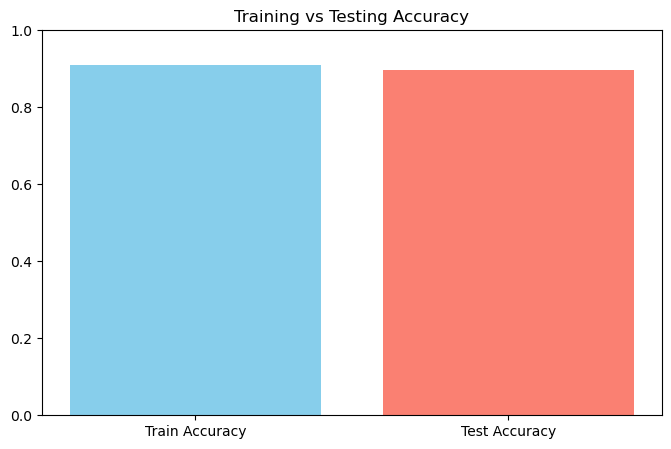

In [9]:
plt.figure(figsize=(8, 5))
plt.bar(['Train Accuracy', 'Test Accuracy'], [train_acc, test_acc], color=['skyblue', 'salmon'])
plt.title("Training vs Testing Accuracy")
plt.ylim(0, 1)
plt.show()

## create confusion matrix

In [10]:
y_test_pred = model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_test_pred)

## visual representation using bar chart

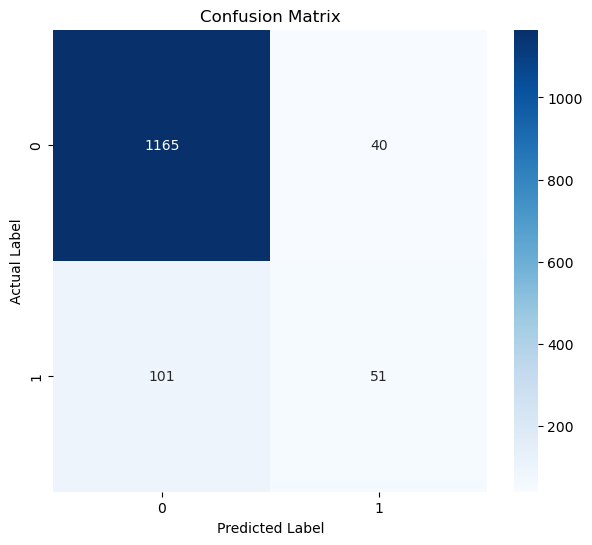

In [11]:
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

## overfitting / underfitting

In [12]:
diff = train_acc - test_acc
if diff > 0.05:
    print("OVERFITTING")
elif train_acc < 0.6:
    print("UNDERFITTING")
else:
    print("Model is FIT")

Model is FIT


In [14]:
print("Training_accuracy:",train_acc)
print("Testing_accuracy:",test_acc)

Training_accuracy: 0.9086599241466498
Testing_accuracy: 0.8960943257184967
